In [5]:
# ==========================================================
# CELL 1: IMPORT LIBRARIES
# ==========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import os

import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.models import Model

from tensorflow.keras.applications import (
    VGG16,
    ResNet50,
    InceptionV3,
    MobileNetV2
)

from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.inception_v3 import preprocess_input as inception_preprocess
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess

from tensorflow.keras.datasets import cifar10

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [10]:
# ==========================================================
# TASK 1: LOAD CIFAR-10
# ==========================================================

(x_train, y_train), (x_test, y_test) = cifar10.load_data()

print("Training images shape :", x_train.shape)
print("Training labels shape :", y_train.shape)
print("Testing images shape  :", x_test.shape)
print("Testing labels shape  :", y_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1827s 11us/step
Training images shape : (50000, 32, 32, 3)
Training labels shape : (50000, 1)
Testing images shape  : (10000, 32, 32, 3)
Testing labels shape  : (10000, 1)


In [11]:
# ==========================================================
# CIFAR-10 CLASS NAMES
# ==========================================================

class_names = [
    "Airplane",
    "Automobile",
    "Bird",
    "Cat",
    "Deer",
    "Dog",
    "Frog",
    "Horse",
    "Ship",
    "Truck"
]

print("Number of classes:", len(class_names))

Number of classes: 10


In [12]:
# ==========================================================
# NORMALIZE PIXEL VALUES
# ==========================================================

x_train_normalized = x_train.astype("float32") / 255.0
x_test_normalized = x_test.astype("float32") / 255.0

print("Minimum pixel value:", x_train_normalized.min())
print("Maximum pixel value:", x_train_normalized.max())

Minimum pixel value: 0.0
Maximum pixel value: 1.0


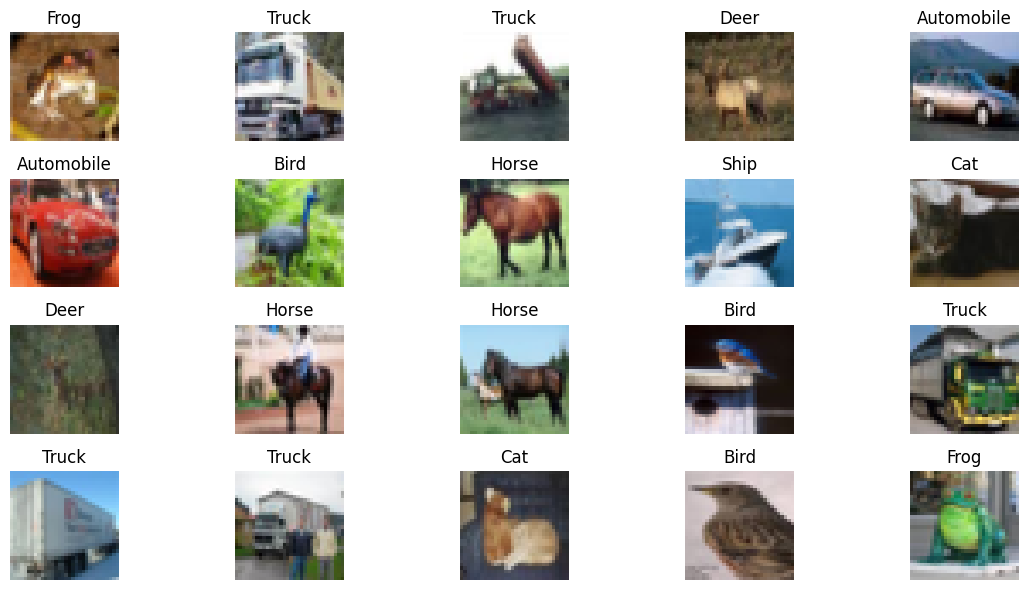

In [13]:
# ==========================================================
# DISPLAY SAMPLE IMAGES
# ==========================================================

plt.figure(figsize=(12, 6))

for i in range(20):
    plt.subplot(4, 5, i + 1)

    plt.imshow(x_train[i])

    label = int(y_train[i][0])
    plt.title(class_names[label])

    plt.axis("off")

plt.tight_layout()
plt.show()

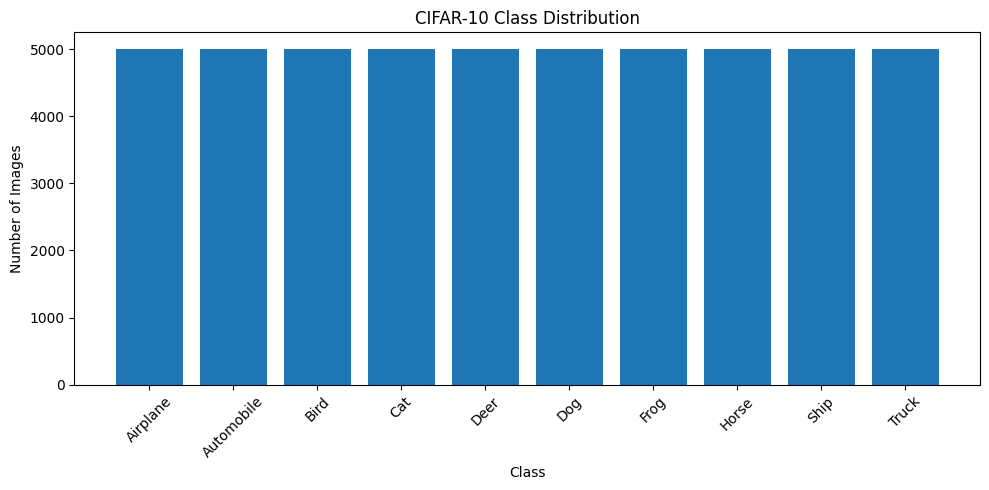

In [14]:
# ==========================================================
# CLASS DISTRIBUTION
# ==========================================================

class_counts = np.bincount(y_train.flatten())

plt.figure(figsize=(10, 5))

plt.bar(class_names, class_counts)

plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.title("CIFAR-10 Class Distribution")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [45]:
# ==========================================================
# CREATE TRAINING AND VALIDATION SETS
# ==========================================================

VAL_SIZE = 5000

x_val = x_train_normalized[-VAL_SIZE:]
y_val = y_train[-VAL_SIZE:]

x_train_final = x_train_normalized[:-VAL_SIZE]
y_train_final = y_train[:-VAL_SIZE]

print("Training:", x_train_final.shape)
print("Validation:", x_val.shape)
print("Testing:", x_test_normalized.shape)

Training: (45000, 32, 32, 3)
Validation: (5000, 32, 32, 3)
Testing: (10000, 32, 32, 3)


In [46]:
# ==========================================================
# DATA AUGMENTATION
# ==========================================================

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.10),
], name="data_augmentation")

In [47]:
# ==========================================================
# TASK 2: VGG16 TRANSFER LEARNING
# ==========================================================

IMG_SIZE = 96
NUM_CLASSES = 10

base_model = tf.keras.applications.VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False

print("VGG16 loaded successfully.")
print("Base model trainable:", base_model.trainable)

VGG16 loaded successfully.
Base model trainable: False


In [48]:
# ==========================================================
# BUILD VGG16 TRANSFER LEARNING MODEL
# ==========================================================

inputs = layers.Input(shape=(32, 32, 3), name="cifar10_input")

x = layers.Resizing(IMG_SIZE, IMG_SIZE, name="resize")(inputs)
x = layers.Rescaling(255.0)(x)                    # <-- NEW LINE, fixes the bug
x = data_augmentation(x)
x = layers.Lambda(tf.keras.applications.vgg16.preprocess_input, name="vgg16_preprocessing")(x)
x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

vgg_model = Model(inputs, outputs, name="VGG16_CIFAR10")
vgg_model.summary()

Model: "VGG16_CIFAR10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ cifar10_input (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resize (Resizing)               │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16_preprocessing (Lambda)    │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 3, 3, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_8      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,781,642 (56.39 MB)

 Trainable params: 66,954 (261.54 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [49]:
# ==========================================================
# TASK 3: COMPILE MODEL
# ==========================================================

vgg_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


In [50]:
# ==========================================================
# CALLBACKS
# ==========================================================

callbacks = [

    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=2,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=1,
        min_lr=1e-6,
        verbose=1
    )
]

In [51]:
# ==========================================================
# TASK 3: TRAIN VGG16 CLASSIFICATION HEAD
# ==========================================================

START_TIME = time.time()

history_vgg = vgg_model.fit(
    x_train_final,
    y_train_final,
    validation_data=(x_val, y_val),
    epochs=5,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)

training_time_initial = time.time() - START_TIME

print(
    f"\nInitial training time: "
    f"{training_time_initial / 60:.2f} minutes"
)

Epoch 1/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 44s 60ms/step - accuracy: 0.5857 - loss: 1.3587 - val_accuracy: 0.7786 - val_loss: 0.6499 - learning_rate: 0.0010
Epoch 2/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 45s 63ms/step - accuracy: 0.7002 - loss: 0.8737 - val_accuracy: 0.8032 - val_loss: 0.5734 - learning_rate: 0.0010
Epoch 3/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 43s 62ms/step - accuracy: 0.7298 - loss: 0.7902 - val_accuracy: 0.7992 - val_loss: 0.5604 - learning_rate: 0.0010
Epoch 4/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 43s 62ms/step - accuracy: 0.7418 - loss: 0.7504 - val_accuracy: 0.8140 - val_loss: 0.5347 - learning_rate: 0.0010
Epoch 5/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 43s 61ms/step - accuracy: 0.7531 - loss: 0.7304 - val_accuracy: 0.8206 - val_loss: 0.5083 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 5.

Initial training time: 3.66 minutes


In [52]:
# ==========================================================
# RECOMPILE FOR FINE-TUNING
# ==========================================================

vgg_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0001
    ),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

print("Model recompiled for fine-tuning.")

Model recompiled for fine-tuning.


In [53]:
# ==========================================================
# FINE-TUNE VGG16
# ==========================================================

fine_tune_callbacks = [

    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=2,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=1,
        min_lr=1e-7,
        verbose=1
    )
]

START_TIME = time.time()

history_finetune = vgg_model.fit(
    x_train_final,
    y_train_final,
    validation_data=(x_val, y_val),
    epochs=5,
    batch_size=32,
    callbacks=fine_tune_callbacks,
    verbose=1
)

training_time_finetune = time.time() - START_TIME

print(
    f"\nFine-tuning time: "
    f"{training_time_finetune / 60:.2f} minutes"
)

Epoch 1/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 50s 35ms/step - accuracy: 0.7705 - loss: 0.6764 - val_accuracy: 0.8270 - val_loss: 0.4919 - learning_rate: 1.0000e-04
Epoch 2/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 48s 34ms/step - accuracy: 0.7744 - loss: 0.6614 - val_accuracy: 0.8324 - val_loss: 0.4861 - learning_rate: 1.0000e-04
Epoch 3/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 48s 34ms/step - accuracy: 0.7796 - loss: 0.6475 - val_accuracy: 0.8338 - val_loss: 0.4832 - learning_rate: 1.0000e-04
Epoch 4/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 48s 34ms/step - accuracy: 0.7818 - loss: 0.6449 - val_accuracy: 0.8324 - val_loss: 0.4816 - learning_rate: 1.0000e-04
Epoch 5/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 48s 34ms/step - accuracy: 0.7816 - loss: 0.6343 - val_accuracy: 0.8338 - val_loss: 0.4808 - learning_rate: 1.0000e-04
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 3.

Fine-tuning time: 4.04 minutes


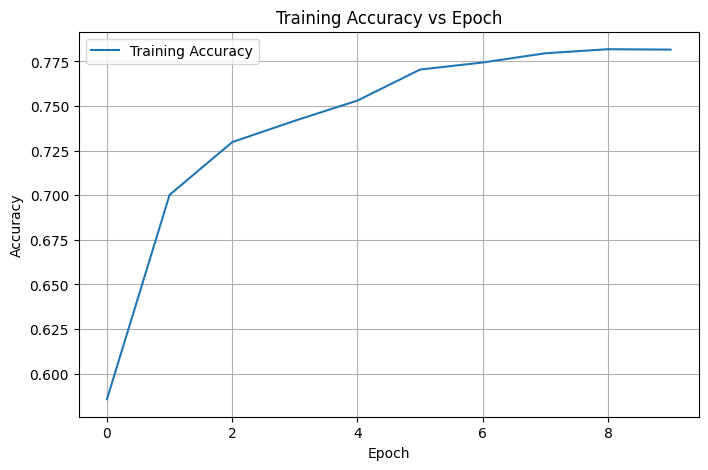

In [54]:
# ==========================================================
# MANDATORY PLOT: TRAINING ACCURACY
# ==========================================================

# Combine histories for plotting
acc = history_vgg.history['accuracy'] + history_finetune.history['accuracy']
val_acc = history_vgg.history['val_accuracy'] + history_finetune.history['val_accuracy']

loss = history_vgg.history['loss'] + history_finetune.history['loss']
val_loss = history_vgg.history['val_loss'] + history_finetune.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(8, 5))

plt.plot(
    epochs_range,
    acc,
    label="Training Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy vs Epoch")

plt.legend()
plt.grid(True)
plt.show()

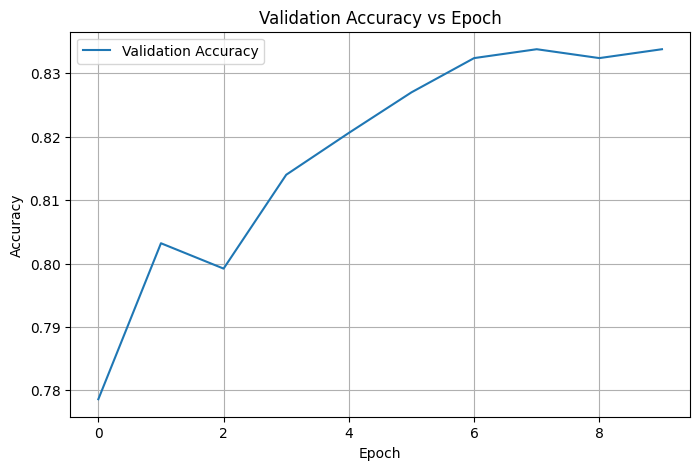

In [55]:
# ==========================================================
# MANDATORY PLOT: VALIDATION ACCURACY
# ==========================================================

plt.figure(figsize=(8, 5))

plt.plot(
    epochs_range,
    val_acc,
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy vs Epoch")

plt.legend()
plt.grid(True)
plt.show()

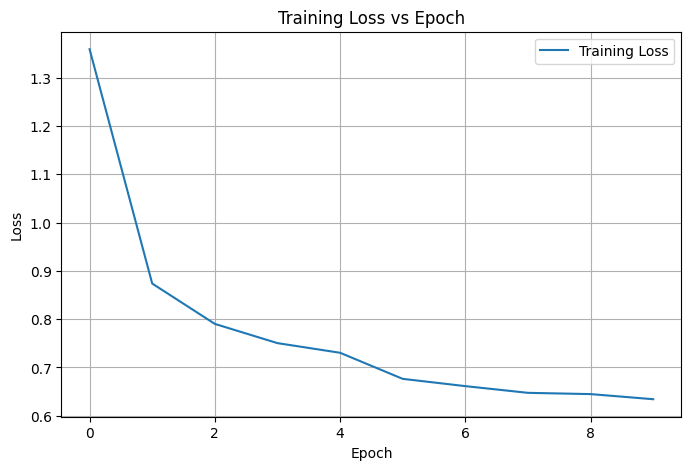

In [56]:
# ==========================================================
# MANDATORY PLOT: TRAINING LOSS
# ==========================================================

plt.figure(figsize=(8, 5))

plt.plot(
    epochs_range,
    loss,
    label="Training Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss vs Epoch")

plt.legend()
plt.grid(True)
plt.show()

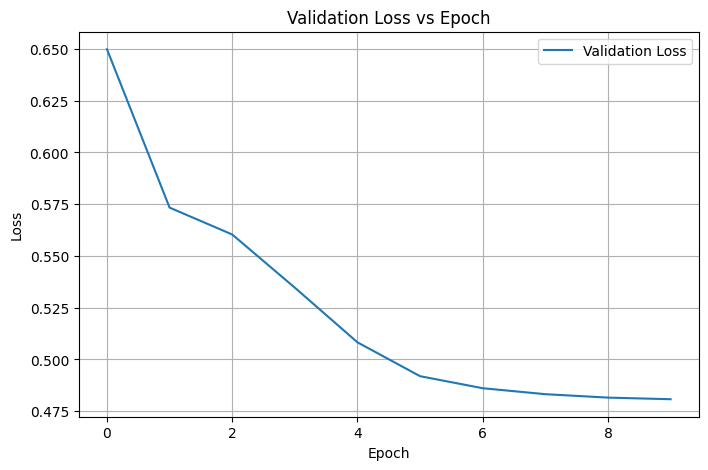

In [57]:
# ==========================================================
# MANDATORY PLOT: VALIDATION LOSS
# ==========================================================

plt.figure(figsize=(8, 5))

plt.plot(
    epochs_range,
    val_loss,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Validation Loss vs Epoch")

plt.legend()
plt.grid(True)
plt.show()

In [58]:
# ==========================================================
# TASK 5: TEST SET EVALUATION
# ==========================================================

test_loss, test_accuracy = vgg_model.evaluate(
    x_test_normalized,
    y_test,
    batch_size=32,
    verbose=1
)

print("\nTest Loss     :", test_loss)
print("Test Accuracy :", test_accuracy)
print("Test Accuracy % :", test_accuracy * 100)

313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 29ms/step - accuracy: 0.8248 - loss: 0.5135

Test Loss     : 0.5135351419448853
Test Accuracy : 0.8248000144958496
Test Accuracy % : 82.48000144958496


In [59]:
# ==========================================================
# GENERATE PREDICTIONS
# ==========================================================

y_prob = vgg_model.predict(
    x_test_normalized,
    batch_size=32,
    verbose=1
)

y_pred = np.argmax(y_prob, axis=1)

y_true = y_test.flatten()

print("Predictions generated successfully.")

313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 29ms/step
Predictions generated successfully.


In [60]:
# ==========================================================
# PRECISION, RECALL AND F1-SCORE
# ==========================================================

precision = precision_score(
    y_true,
    y_pred,
    average="weighted"
)

recall = recall_score(
    y_true,
    y_pred,
    average="weighted"
)

f1 = f1_score(
    y_true,
    y_pred,
    average="weighted"
)

accuracy = accuracy_score(
    y_true,
    y_pred
)

print("Accuracy  :", accuracy)
print("Precision :", precision)
print("Recall    :", recall)
print("F1-score  :", f1)

Accuracy  : 0.8248
Precision : 0.8251696476700253
Recall    : 0.8248
F1-score  : 0.8242598703036993


In [61]:
# ==========================================================
# CLASSIFICATION REPORT
# ==========================================================

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

    Airplane       0.86      0.81      0.84      1000
  Automobile       0.89      0.89      0.89      1000
        Bird       0.82      0.76      0.79      1000
         Cat       0.71      0.69      0.70      1000
        Deer       0.75      0.82      0.78      1000
         Dog       0.81      0.74      0.77      1000
        Frog       0.82      0.88      0.85      1000
       Horse       0.86      0.85      0.86      1000
        Ship       0.86      0.91      0.89      1000
       Truck       0.87      0.89      0.88      1000

    accuracy                           0.82     10000
   macro avg       0.83      0.82      0.82     10000
weighted avg       0.83      0.82      0.82     10000



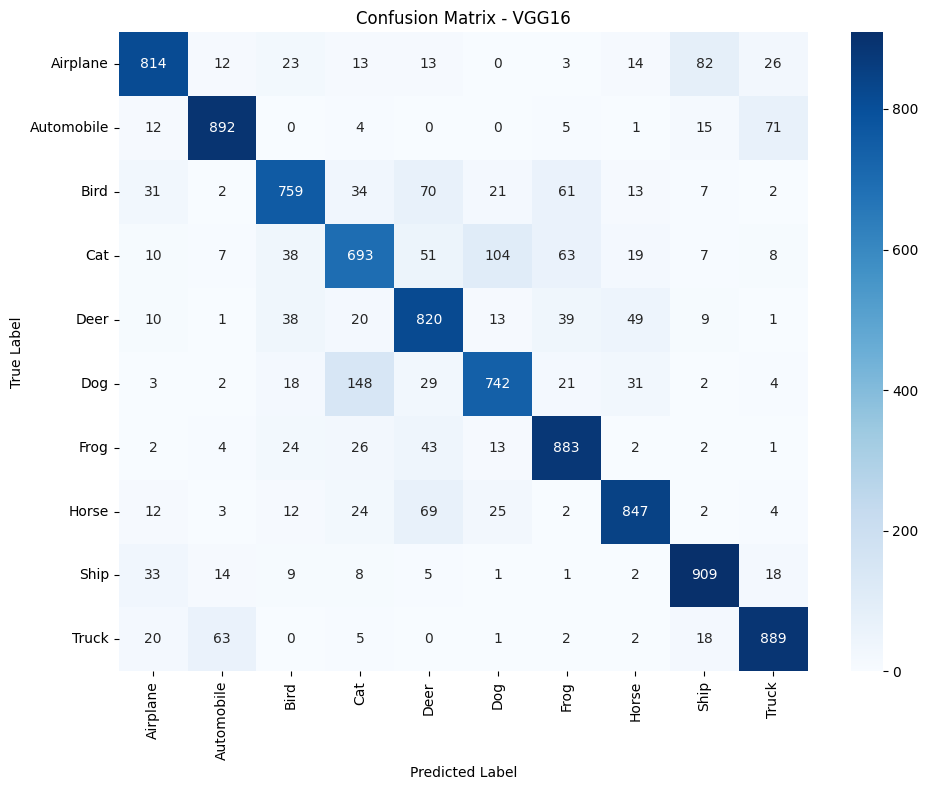

In [62]:
# ==========================================================
# MANDATORY PLOT: CONFUSION MATRIX
# ==========================================================

cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - VGG16")

plt.tight_layout()
plt.show()

Number of misclassified images: 1752


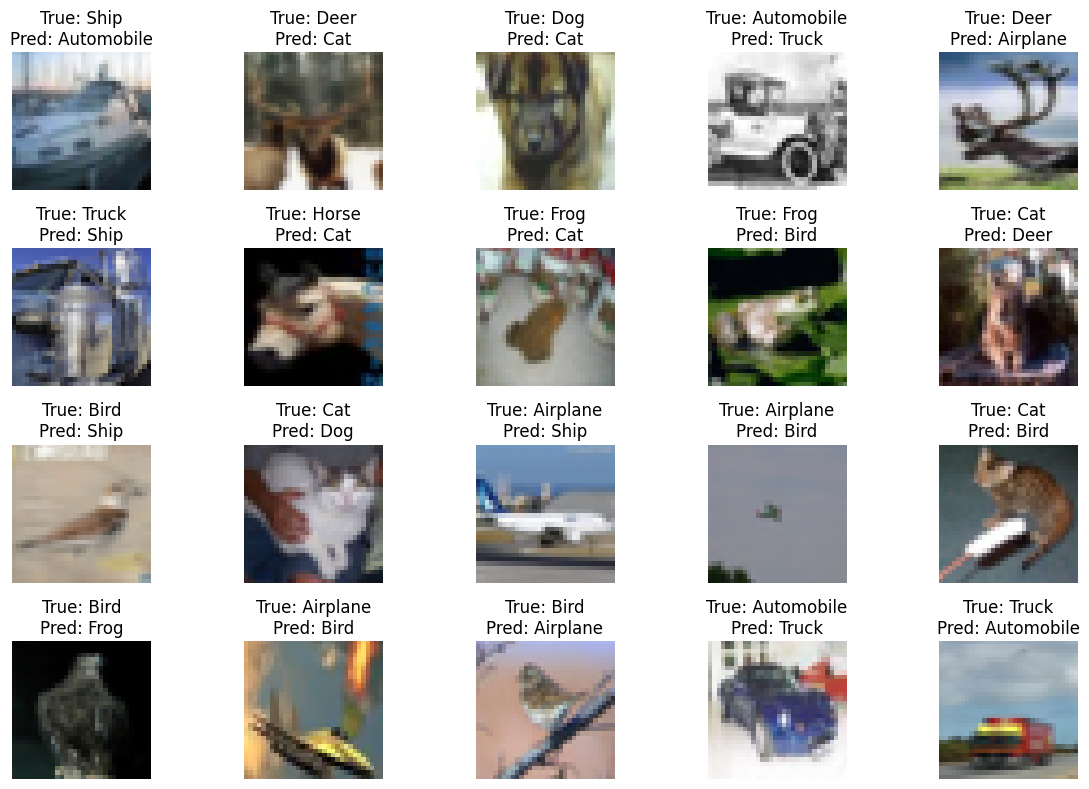

In [63]:
# ==========================================================
# OPTIONAL: MISCLASSIFIED IMAGES
# ==========================================================

misclassified = np.where(
    y_true != y_pred
)[0]

print(
    "Number of misclassified images:",
    len(misclassified)
)

plt.figure(figsize=(12, 8))

for i, idx in enumerate(misclassified[:20]):

    plt.subplot(4, 5, i + 1)

    plt.imshow(x_test[idx])

    plt.title(
        f"True: {class_names[y_true[idx]]}\n"
        f"Pred: {class_names[y_pred[idx]]}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [64]:
# ==========================================================
# RESULTS TABLE
# ==========================================================

training_accuracy = max(acc)

total_training_time = (
    training_time_initial
    + training_time_finetune
)

total_parameters = vgg_model.count_params()

results_table = pd.DataFrame({
    "Metric": [
        "Training Accuracy",
        "Testing Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "Training Time (minutes)",
        "Total Parameters"
    ],

    "Value": [
        training_accuracy,
        test_accuracy,
        precision,
        recall,
        f1,
        total_training_time / 60,
        total_parameters
    ]
})

results_table

,Metric,Value
0,Training Accuracy,7.818444e-01
1,Testing Accuracy,8.248000e-01
2,Precision,8.251696e-01
3,Recall,8.248000e-01
4,F1-score,8.242599e-01
5,Training Time (minutes),7.697276e+00
6,Total Parameters,1.478164e+07


In [65]:
# ==========================================================
# HYPERPARAMETER EXPERIMENT FUNCTION
# ==========================================================

def build_vgg_experiment(learning_rate=0.001, optimizer_name="Adam", dense_units=128):

    base = VGG16(weights="imagenet", include_top=False, input_shape=(96, 96, 3))
    base.trainable = False

    inputs = layers.Input(shape=(32, 32, 3))
    x = layers.Resizing(96, 96)(inputs)
    x = layers.Rescaling(255.0)(x)                # <-- NEW LINE, fixes the bug
    x = layers.Lambda(vgg_preprocess)(x)
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(dense_units, activation="relu")(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(10, activation="softmax")(x)

    model = Model(inputs, outputs)

    if optimizer_name == "Adam":
        optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    else:
        optimizer = tf.keras.optimizers.SGD(learning_rate=learning_rate, momentum=0.9)

    model.compile(optimizer=optimizer, loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

In [66]:
# ==========================================================
# LEARNING RATE COMPARISON
# ==========================================================

learning_rates = [0.001, 0.0001]

lr_results = []

for lr in learning_rates:

    print("\n" + "=" * 50)
    print("Testing Learning Rate:", lr)
    print("=" * 50)

    model = build_vgg_experiment(
        learning_rate=lr,
        optimizer_name="Adam",
        dense_units=128
    )

    start = time.time()

    hist = model.fit(
        x_train_final,
        y_train_final,
        validation_data=(x_val, y_val),
        epochs=3,
        batch_size=32,
        verbose=1
    )

    elapsed = time.time() - start

    best_val_accuracy = max(
        hist.history["val_accuracy"]
    )

    lr_results.append({
        "Learning Rate": lr,
        "Best Validation Accuracy": best_val_accuracy,
        "Training Time (min)": elapsed / 60
    })

lr_results_df = pd.DataFrame(lr_results)

lr_results_df


Testing Learning Rate: 0.001
Epoch 1/3
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 76s 50ms/step - accuracy: 0.6785 - loss: 1.0919 - val_accuracy: 0.7956 - val_loss: 0.5840
Epoch 2/3
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 66s 47ms/step - accuracy: 0.7780 - loss: 0.6564 - val_accuracy: 0.8116 - val_loss: 0.5304
Epoch 3/3
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 67s 47ms/step - accuracy: 0.8006 - loss: 0.5854 - val_accuracy: 0.8204 - val_loss: 0.5164

Testing Learning Rate: 0.0001
Epoch 1/3
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 74s 50ms/step - accuracy: 0.4458 - loss: 2.7084 - val_accuracy: 0.6722 - val_loss: 1.0150
Epoch 2/3
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 67s 47ms/step - accuracy: 0.6332 - loss: 1.1528 - val_accuracy: 0.7448 - val_loss: 0.7814
Epoch 3/3
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 82s 48ms/step - accuracy: 0.6967 - loss: 0.9264 - val_accuracy: 0.7730 - val_loss: 0.6847


,Learning Rate,Best Validation Accuracy,Training Time (min)
0,0.0010,0.8204,3.505511
1,0.0001,0.7730,3.739559


In [67]:
# ==========================================================
# DENSE LAYER SIZE COMPARISON
# ==========================================================

dense_results = []

for units in [128, 256]:

    print("\n" + "=" * 50)
    print("Testing Dense Units:", units)
    print("=" * 50)

    model = build_vgg_experiment(
        learning_rate=0.0001,
        optimizer_name="Adam",
        dense_units=units
    )

    hist = model.fit(
        x_train_final,
        y_train_final,
        validation_data=(x_val, y_val),
        epochs=3,
        batch_size=32,
        verbose=1
    )

    dense_results.append({
        "Dense Units": units,
        "Best Validation Accuracy":
            max(hist.history["val_accuracy"])
    })

dense_results_df = pd.DataFrame(
    dense_results
)

dense_results_df


Testing Dense Units: 128
Epoch 1/3
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 75s 50ms/step - accuracy: 0.4471 - loss: 2.6225 - val_accuracy: 0.6788 - val_loss: 0.9679
Epoch 2/3
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 67s 48ms/step - accuracy: 0.6410 - loss: 1.1166 - val_accuracy: 0.7440 - val_loss: 0.7536
Epoch 3/3
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 67s 47ms/step - accuracy: 0.7040 - loss: 0.9005 - val_accuracy: 0.7670 - val_loss: 0.6687

Testing Dense Units: 256
Epoch 1/3
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 73s 50ms/step - accuracy: 0.5481 - loss: 2.2910 - val_accuracy: 0.7388 - val_loss: 0.8254
Epoch 2/3
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 66s 47ms/step - accuracy: 0.6986 - loss: 0.9652 - val_accuracy: 0.7734 - val_loss: 0.6765
Epoch 3/3
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 66s 47ms/step - accuracy: 0.7484 - loss: 0.7667 - val_accuracy: 0.7900 - val_loss: 0.6132


,Dense Units,Best Validation Accuracy
0,128,0.767
1,256,0.790


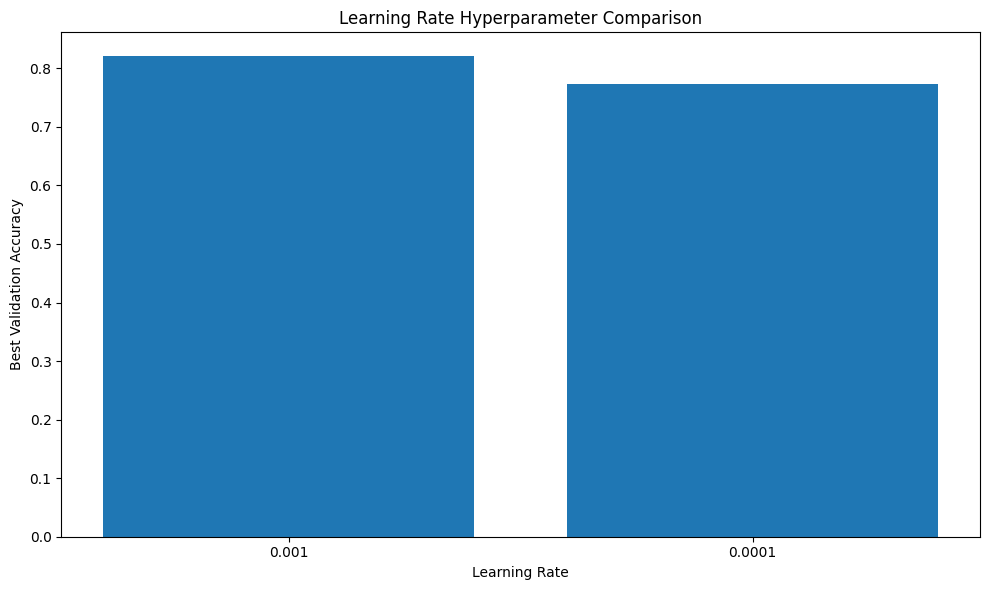

In [68]:
# ==========================================================
# HYPERPARAMETER SEARCH RESULTS
# ==========================================================

plt.figure(figsize=(10, 6))

plt.bar(
    lr_results_df["Learning Rate"].astype(str),
    lr_results_df["Best Validation Accuracy"]
)

plt.xlabel("Learning Rate")
plt.ylabel("Best Validation Accuracy")
plt.title("Learning Rate Hyperparameter Comparison")

plt.tight_layout()
plt.show()

In [69]:
# ==========================================================
# BUILD RESNET50
# ==========================================================

resnet_base = tf.keras.applications.ResNet50(
    weights="imagenet", include_top=False, input_shape=(96, 96, 3)
)
resnet_base.trainable = False

inputs_r = layers.Input(shape=(32, 32, 3))
x = layers.Resizing(96, 96)(inputs_r)
x = layers.Rescaling(255.0)(x)
x = layers.Lambda(tf.keras.applications.resnet50.preprocess_input)(x)
x = resnet_base(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.4)(x)
outputs_r = layers.Dense(10, activation="softmax")(x)

resnet_model = Model(inputs_r, outputs_r, name="ResNet50_CIFAR10")
resnet_model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "ResNet50_CIFAR10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_26 (InputLayer)     │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing_10 (Resizing)          │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_6 (Rescaling)         │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_10 (Lambda)              │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 3, 3, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_13     │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,851,274 (90.99 MB)

 Trainable params: 263,562 (1.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [70]:
# ==========================================================
# COMPILE RESNET50
# ==========================================================

resnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [71]:
# ==========================================================
# TRAIN RESNET50
# ==========================================================

start = time.time()

history_resnet = resnet_model.fit(
    x_train_final,
    y_train_final,
    validation_data=(x_val, y_val),
    epochs=10,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

resnet_training_time = time.time() - start

print(
    f"ResNet50 training time: "
    f"{resnet_training_time / 60:.2f} minutes"
)

Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 56s 31ms/step - accuracy: 0.7776 - loss: 0.6737 - val_accuracy: 0.8454 - val_loss: 0.4517 - learning_rate: 0.0010
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 33s 23ms/step - accuracy: 0.8292 - loss: 0.5073 - val_accuracy: 0.8520 - val_loss: 0.4356 - learning_rate: 0.0010
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 32s 23ms/step - accuracy: 0.8450 - loss: 0.4566 - val_accuracy: 0.8586 - val_loss: 0.4215 - learning_rate: 0.0010
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 33s 23ms/step - accuracy: 0.8569 - loss: 0.4255 - val_accuracy: 0.8592 - val_loss: 0.4199 - learning_rate: 0.0010
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 32s 23ms/step - accuracy: 0.8619 - loss: 0.3983 - val_accuracy: 0.8658 - val_loss: 0.4058 - learning_rate: 0.0010
Epoch 6/10
1405/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.8709 - loss: 0.3732
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 32s 23ms/step - accuracy

In [72]:
# ==========================================================
# RESNET50 FINE-TUNING
# ==========================================================

resnet_base.trainable = True

# Freeze most layers
for layer in resnet_base.layers[:-30]:
    layer.trainable = False

# Last 30 layers are trainable
for layer in resnet_base.layers[-30:]:
    layer.trainable = True

resnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Trainable layers in ResNet50:")

for layer in resnet_base.layers:
    if layer.trainable:
        print(layer.name)

Trainable layers in ResNet50:
conv5_block1_1_relu
conv5_block1_2_conv
conv5_block1_2_bn
conv5_block1_2_relu
conv5_block1_0_conv
conv5_block1_3_conv
conv5_block1_0_bn
conv5_block1_3_bn
conv5_block1_add
conv5_block1_out
conv5_block2_1_conv
conv5_block2_1_bn
conv5_block2_1_relu
conv5_block2_2_conv
conv5_block2_2_bn
conv5_block2_2_relu
conv5_block2_3_conv
conv5_block2_3_bn
conv5_block2_add
conv5_block2_out
conv5_block3_1_conv
conv5_block3_1_bn
conv5_block3_1_relu
conv5_block3_2_conv
conv5_block3_2_bn
conv5_block3_2_relu
conv5_block3_3_conv
conv5_block3_3_bn
conv5_block3_add
conv5_block3_out


In [73]:
# ==========================================================
# FINE-TUNE RESNET50
# ==========================================================

start = time.time()

history_resnet_ft = resnet_model.fit(
    x_train_final,
    y_train_final,
    validation_data=(x_val, y_val),
    epochs=5,
    batch_size=32,
    callbacks=fine_tune_callbacks,
    verbose=1
)

resnet_finetune_time = time.time() - start

print(
    f"ResNet50 fine-tuning time: "
    f"{resnet_finetune_time / 60:.2f} minutes"
)

Epoch 1/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 84s 45ms/step - accuracy: 0.8728 - loss: 0.3774 - val_accuracy: 0.8916 - val_loss: 0.3243 - learning_rate: 1.0000e-04
Epoch 2/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 49s 35ms/step - accuracy: 0.9333 - loss: 0.2038 - val_accuracy: 0.9004 - val_loss: 0.3064 - learning_rate: 1.0000e-04
Epoch 3/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.9595 - loss: 0.1221
Epoch 3: ReduceLROnPlateau reducing learning rate to 2.9999999242136255e-05.
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 49s 35ms/step - accuracy: 0.9565 - loss: 0.1305 - val_accuracy: 0.9066 - val_loss: 0.3390 - learning_rate: 1.0000e-04
Epoch 4/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.9810 - loss: 0.0629
Epoch 4: ReduceLROnPlateau reducing learning rate to 8.999999772640877e-06.
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 49s 35ms/step - accuracy: 0.9834 - loss: 0.0544 - val_accuracy: 0.9150 - val_loss: 0.3355 - learning_rate: 3.0000e-05
Epoch 5/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step -

In [74]:
# ==========================================================
# LENET-5 STYLE MODEL FOR CIFAR-10
# ==========================================================

def build_lenet():

    model = models.Sequential([

        layers.Input(shape=(32, 32, 3)),

        layers.Conv2D(
            6,
            kernel_size=5,
            activation="tanh",
            padding="same"
        ),

        layers.AveragePooling2D(pool_size=2),

        layers.Conv2D(
            16,
            kernel_size=5,
            activation="tanh"
        ),

        layers.AveragePooling2D(pool_size=2),

        layers.Flatten(),

        layers.Dense(
            120,
            activation="tanh"
        ),

        layers.Dense(
            84,
            activation="tanh"
        ),

        layers.Dense(
            10,
            activation="softmax"
        )
    ])

    return model


lenet_model = build_lenet()

lenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

lenet_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 6)      │           456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 16, 16, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 12, 12, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 6, 6, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 120)            │        69,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 83,126 (324.71 KB)

 Trainable params: 83,126 (324.71 KB)

 Non-trainable params: 0 (0.00 B)

In [75]:
# ==========================================================
# TRAIN LENET
# ==========================================================

start = time.time()

history_lenet = lenet_model.fit(
    x_train_final,
    y_train_final,
    validation_data=(x_val, y_val),
    epochs=10,
    batch_size=32,
    verbose=1
)

lenet_time = time.time() - start

Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.3723 - loss: 1.7718 - val_accuracy: 0.4154 - val_loss: 1.6561
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.4559 - loss: 1.5332 - val_accuracy: 0.4864 - val_loss: 1.4524
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.5028 - loss: 1.4030 - val_accuracy: 0.4968 - val_loss: 1.4259
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.5308 - loss: 1.3274 - val_accuracy: 0.5270 - val_loss: 1.3737
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.5530 - loss: 1.2657 - val_accuracy: 0.5374 - val_loss: 1.3350
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.5686 - loss: 1.2173 - val_accuracy: 0.5364 - val_loss: 1.3303
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.5841 - loss: 1.1734 - val_accuracy: 0.5418 - val_loss: 1.3245
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.5973 - loss: 1.1338 -

In [76]:
# ==========================================================
# ALEXNET-STYLE MODEL FOR CIFAR-10
# ==========================================================

def build_alexnet():

    model = models.Sequential([

        layers.Input(shape=(32, 32, 3)),

        layers.Conv2D(
            64,
            kernel_size=3,
            padding="same",
            activation="relu"
        ),

        layers.BatchNormalization(),

        layers.MaxPooling2D(pool_size=2),

        layers.Conv2D(
            192,
            kernel_size=3,
            padding="same",
            activation="relu"
        ),

        layers.BatchNormalization(),

        layers.MaxPooling2D(pool_size=2),

        layers.Conv2D(
            384,
            kernel_size=3,
            padding="same",
            activation="relu"
        ),

        layers.Conv2D(
            256,
            kernel_size=3,
            padding="same",
            activation="relu"
        ),

        layers.Conv2D(
            256,
            kernel_size=3,
            padding="same",
            activation="relu"
        ),

        layers.MaxPooling2D(pool_size=2),

        layers.Flatten(),

        layers.Dense(
            256,
            activation="relu"
        ),

        layers.Dropout(0.5),

        layers.Dense(
            256,
            activation="relu"
        ),

        layers.Dropout(0.5),

        layers.Dense(
            10,
            activation="softmax"
        )
    ])

    return model


alexnet_model = build_alexnet()

alexnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

alexnet_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 192)    │       110,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 192)    │           768 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 192)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 384)      │       663,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 256)      │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 256)            │     1,048,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,369,802 (12.85 MB)

 Trainable params: 3,369,290 (12.85 MB)

 Non-trainable params: 512 (2.00 KB)

In [77]:
# ==========================================================
# TRAIN ALEXNET
# ==========================================================

start = time.time()

history_alexnet = alexnet_model.fit(
    x_train_final,
    y_train_final,
    validation_data=(x_val, y_val),
    epochs=10,
    batch_size=32,
    verbose=1
)

alexnet_time = time.time() - start

Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 32s 17ms/step - accuracy: 0.3947 - loss: 1.6460 - val_accuracy: 0.4468 - val_loss: 1.5448
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step - accuracy: 0.5593 - loss: 1.2614 - val_accuracy: 0.5562 - val_loss: 1.2187
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step - accuracy: 0.6271 - loss: 1.0903 - val_accuracy: 0.6406 - val_loss: 1.0586
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 17s 12ms/step - accuracy: 0.6640 - loss: 0.9861 - val_accuracy: 0.6532 - val_loss: 1.0510
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.6935 - loss: 0.9145 - val_accuracy: 0.6626 - val_loss: 0.9828
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step - accuracy: 0.7112 - loss: 0.8595 - val_accuracy: 0.6494 - val_loss: 1.0328
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 17s 12ms/step - accuracy: 0.7336 - loss: 0.8041 - val_accuracy: 0.6996 - val_loss: 0.8991
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - accuracy: 0.7506 -

In [78]:
# ==========================================================
# GOOGLENET / INCEPTIONV3
# ==========================================================

inception_base = InceptionV3(weights="imagenet", include_top=False, input_shape=(96, 96, 3))
inception_base.trainable = False

inputs = layers.Input(shape=(32, 32, 3))
x = layers.Resizing(96, 96)(inputs)
x = layers.Rescaling(255.0)(x)                    # <-- NEW LINE, fixes the bug
x = layers.Lambda(inception_preprocess)(x)
x = inception_base(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(10, activation="softmax")(x)

inception_model = Model(inputs, outputs)
inception_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy", metrics=["accuracy"]
)
inception_model.summary()

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_30 (InputLayer)     │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing_11 (Resizing)          │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_7 (Rescaling)         │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_11 (Lambda)              │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ inception_v3 (Functional)       │ (None, 1, 1, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_14     │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,066,346 (84.18 MB)

 Trainable params: 263,562 (1.01 MB)

 Non-trainable params: 21,802,784 (83.17 MB)

In [79]:
# ==========================================================
# TRAIN INCEPTION
# ==========================================================

start = time.time()
history_inception = inception_model.fit(
    x_train_final, y_train_final,
    validation_data=(x_val, y_val),
    epochs=5, batch_size=32, verbose=1
)
inception_time = time.time() - start

Epoch 1/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 56s 29ms/step - accuracy: 0.5746 - loss: 1.2528 - val_accuracy: 0.6848 - val_loss: 0.9216
Epoch 2/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 24s 17ms/step - accuracy: 0.6440 - loss: 1.0386 - val_accuracy: 0.6940 - val_loss: 0.8918
Epoch 3/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 23s 17ms/step - accuracy: 0.6675 - loss: 0.9700 - val_accuracy: 0.6974 - val_loss: 0.8813
Epoch 4/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 23s 17ms/step - accuracy: 0.6755 - loss: 0.9329 - val_accuracy: 0.7006 - val_loss: 0.8602
Epoch 5/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 23s 17ms/step - accuracy: 0.6910 - loss: 0.8967 - val_accuracy: 0.6936 - val_loss: 0.8745


In [80]:
# ==========================================================
# MODEL EVALUATION HELPER
# ==========================================================

def evaluate_model(model, x_test_data, y_test_data):

    loss, accuracy = model.evaluate(
        x_test_data,
        y_test_data,
        batch_size=32,
        verbose=0
    )

    return accuracy

In [81]:
# ==========================================================
# CNN ARCHITECTURE COMPARISON
# ==========================================================

architecture_results = []

# LeNet
lenet_acc = evaluate_model(
    lenet_model,
    x_test_normalized,
    y_test
)

architecture_results.append({
    "Model": "LeNet-5",
    "Parameters": lenet_model.count_params(),
    "Accuracy (%)": lenet_acc * 100,
    "Training Time (min)": lenet_time / 60
})


# AlexNet
alexnet_acc = evaluate_model(
    alexnet_model,
    x_test_normalized,
    y_test
)

architecture_results.append({
    "Model": "AlexNet",
    "Parameters": alexnet_model.count_params(),
    "Accuracy (%)": alexnet_acc * 100,
    "Training Time (min)": alexnet_time / 60
})


# VGG16
vgg_acc = evaluate_model(
    vgg_model,
    x_test_normalized,
    y_test
)

architecture_results.append({
    "Model": "VGG16",
    "Parameters": vgg_model.count_params(),
    "Accuracy (%)": vgg_acc * 100,
    "Training Time (min)": total_training_time / 60
})


# ResNet50
resnet_acc = evaluate_model(
    resnet_model,
    x_test_normalized,
    y_test
)

architecture_results.append({
    "Model": "ResNet50",
    "Parameters": resnet_model.count_params(),
    "Accuracy (%)": resnet_acc * 100,
    "Training Time (min)":
        (resnet_training_time + resnet_finetune_time) / 60
})


architecture_df = pd.DataFrame(
    architecture_results
)

architecture_df

,Model,Parameters,Accuracy (%),Training Time (min)
0,LeNet-5,83126,52.789998,0.965288
1,AlexNet,3369802,70.240003,3.079184
2,VGG16,14781642,82.480001,7.697276
3,ResNet50,23851274,91.710001,10.525900


In [82]:
inception_acc = evaluate_model(
    inception_model,
    x_test_normalized,
    y_test
)

architecture_results.append({
    "Model": "GoogleNet / InceptionV3",
    "Parameters": inception_model.count_params(),
    "Accuracy (%)": inception_acc * 100,
    "Training Time (min)": inception_time / 60
})

In [83]:
architecture_df = pd.DataFrame(
    architecture_results
)

architecture_df

,Model,Parameters,Accuracy (%),Training Time (min)
0,LeNet-5,83126,52.789998,0.965288
1,AlexNet,3369802,70.240003,3.079184
2,VGG16,14781642,82.480001,7.697276
3,ResNet50,23851274,91.710001,10.525900
4,GoogleNet / InceptionV3,22066346,69.120002,2.517263


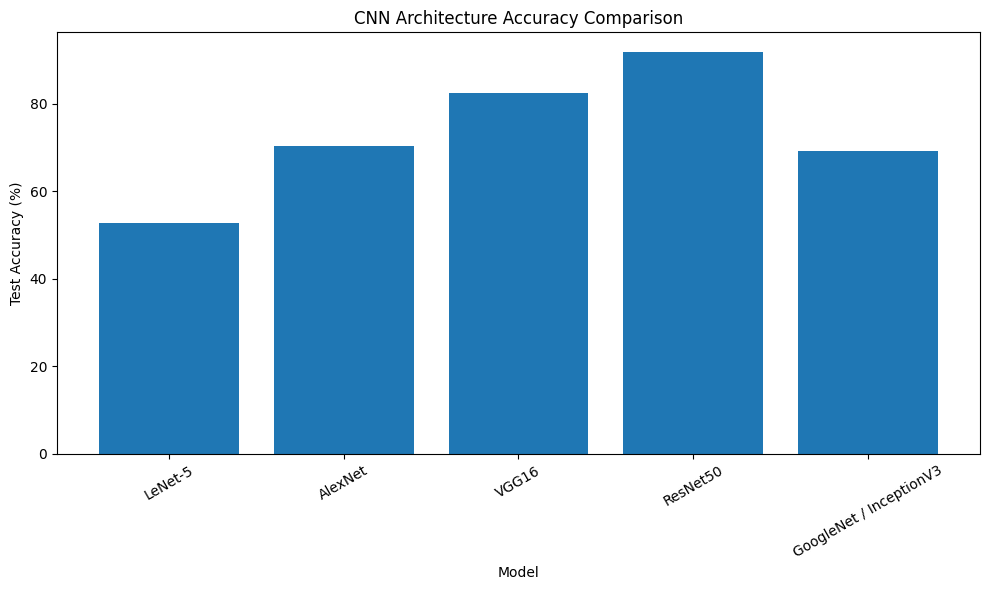

In [84]:
# ==========================================================
# MODEL ACCURACY COMPARISON
# ==========================================================

plt.figure(figsize=(10, 6))

plt.bar(
    architecture_df["Model"],
    architecture_df["Accuracy (%)"]
)

plt.xlabel("Model")
plt.ylabel("Test Accuracy (%)")
plt.title("CNN Architecture Accuracy Comparison")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [85]:
best_frozen_accuracy = max(history_vgg.history['val_accuracy'])
best_finetuned_accuracy = max(history_finetune.history['val_accuracy'])

In [86]:
# ==========================================================
# FROZEN VS FINE-TUNED COMPARISON
# ==========================================================

comparison = pd.DataFrame({
    "Training Stage": [
        "Frozen VGG16",
        "Fine-Tuned VGG16"
    ],

    "Best Validation Accuracy": [
        best_frozen_accuracy,
        best_finetuned_accuracy
    ]
})

print(comparison)

     Training Stage  Best Validation Accuracy
0      Frozen VGG16                    0.8206
1  Fine-Tuned VGG16                    0.8338


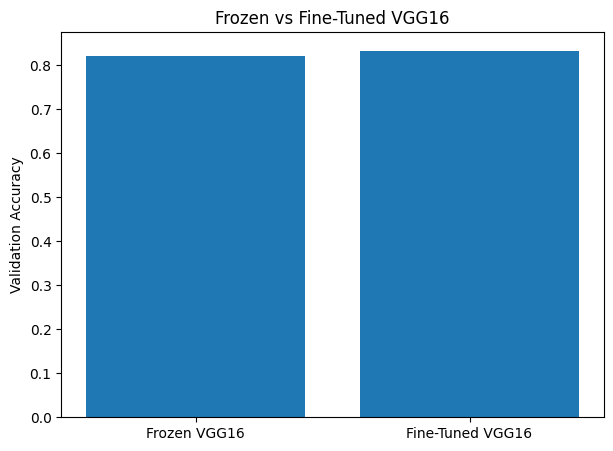

In [87]:
plt.figure(figsize=(7, 5))

plt.bar(
    comparison["Training Stage"],
    comparison["Best Validation Accuracy"]
)

plt.ylabel("Validation Accuracy")
plt.title("Frozen vs Fine-Tuned VGG16")

plt.show()

In [1]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
